# Suite 3 — Explainable AI & Feature Dynamics

**Goal:** verify the models read the physical priors and thermodynamic variables correctly post-rework.

SHAP beeswarms are recomputed here from the production tree models on the ML matrix. EBM interaction structure comes from the persisted `results/ebm_*_importance.csv`. TFT attention is embedded from the `explain_tft.py` artefacts (re-running the checkpoint is heavy and out of scope for a visualization notebook).

In [1]:
import os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Anchor to repo root so relative data/results paths work whether the notebook
# is launched from notebooks/ or the project root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.3,
})
FIG = "results/figures"
os.makedirs(FIG, exist_ok=True)

def save(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p)
    print("saved ->", p)
    return p

# Consistent model palette across every suite.
MODEL_ORDER = ["persistence", "climatology", "lightgbm", "xgboost", "ebm", "bilstm", "tft"]
PAL = dict(zip(MODEL_ORDER, sns.color_palette("colorblind", len(MODEL_ORDER))))
BASELINES = {"persistence", "climatology"}


In [2]:
import joblib, shap
from src.features.schema import FEATURE_COLS
mat = pd.read_parquet("data/processed/ml_training_matrix.parquet")
mat.index = pd.to_datetime(mat.index, utc=True)
X = mat[FEATURE_COLS]
Xs = X.sample(min(3000, len(X)), random_state=42)  # subsample for a legible beeswarm
print("SHAP background sample:", Xs.shape)

SHAP background sample: (3000, 9)


## 3a — SHAP beeswarm summaries (LightGBM & XGBoost, wind & solar)

saved -> results/figures/s3_shap_lightgbm_wind_beeswarm.png


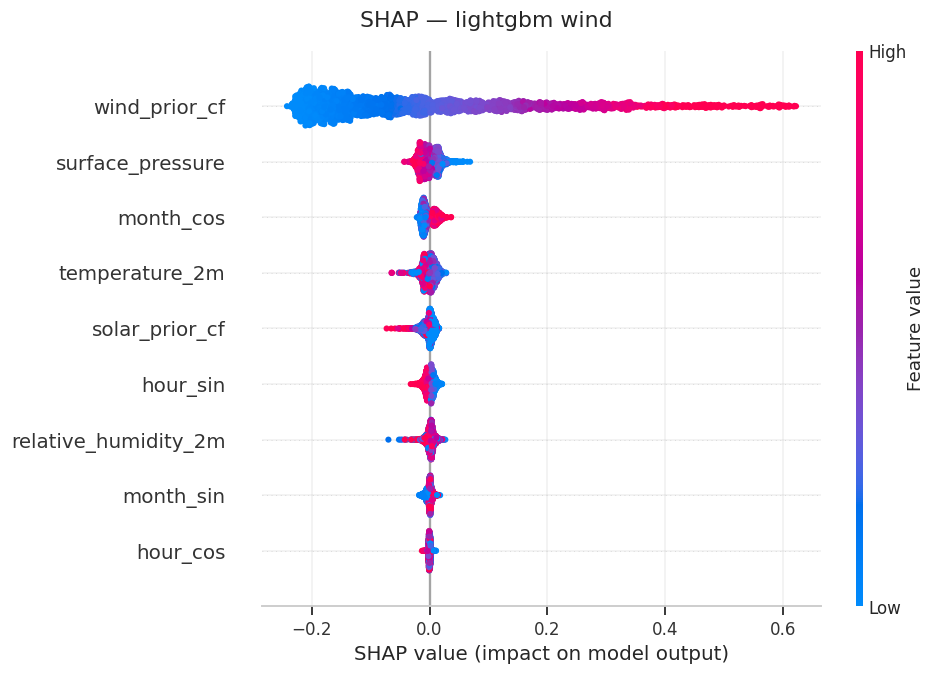

saved -> results/figures/s3_shap_lightgbm_solar_beeswarm.png


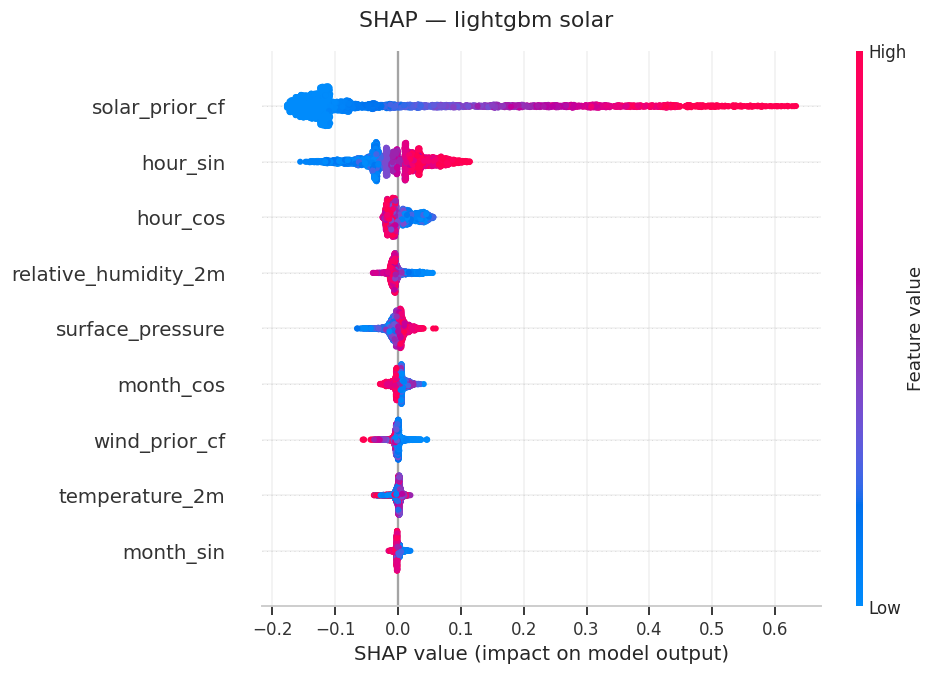

saved -> results/figures/s3_shap_xgboost_wind_beeswarm.png


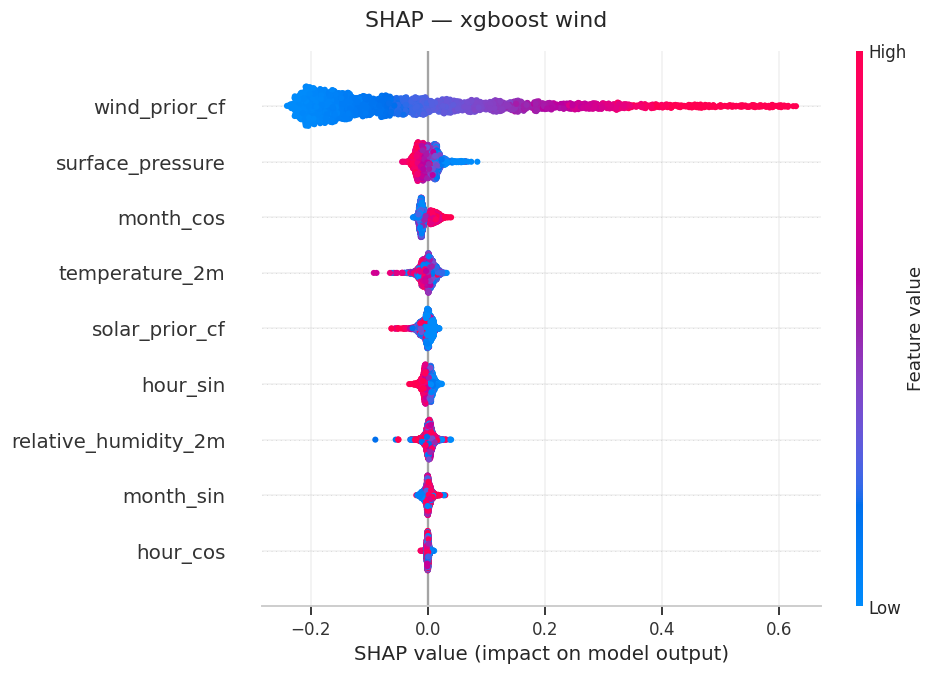

saved -> results/figures/s3_shap_xgboost_solar_beeswarm.png


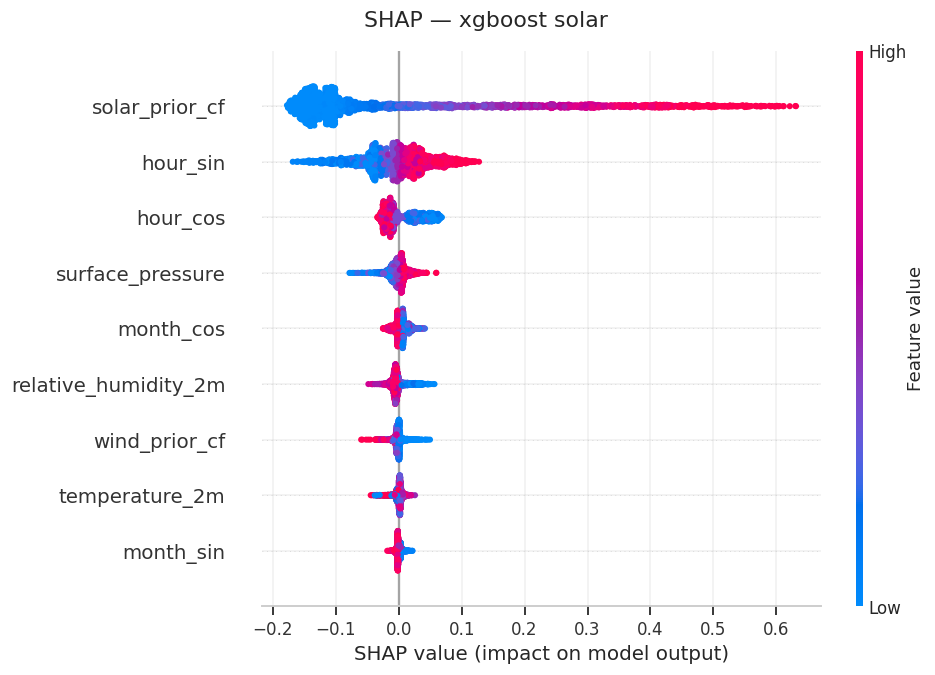

In [3]:
for model in ["lightgbm","xgboost"]:
    for tech in ["wind","solar"]:
        est = joblib.load(f"models/{model}_{tech}.pkl")
        explainer = shap.TreeExplainer(est)
        sv = explainer.shap_values(Xs)
        plt.figure(figsize=(9, 6))
        shap.summary_plot(sv, Xs, show=False, plot_size=None)
        fig = plt.gcf(); fig.suptitle(f"SHAP — {model} {tech}", y=1.02)
        save(fig, f"s3_shap_{model}_{tech}_beeswarm.png"); plt.show()

## 3b — EBM interaction heatmaps (pairwise feature interactions)

Diagonal = main effect, off-diagonal = pairwise interaction strength. Highlights the `wind_prior × solar_prior` and `prior × time-of-day` terms.

saved -> results/figures/s3_ebm_interaction_heatmap.png


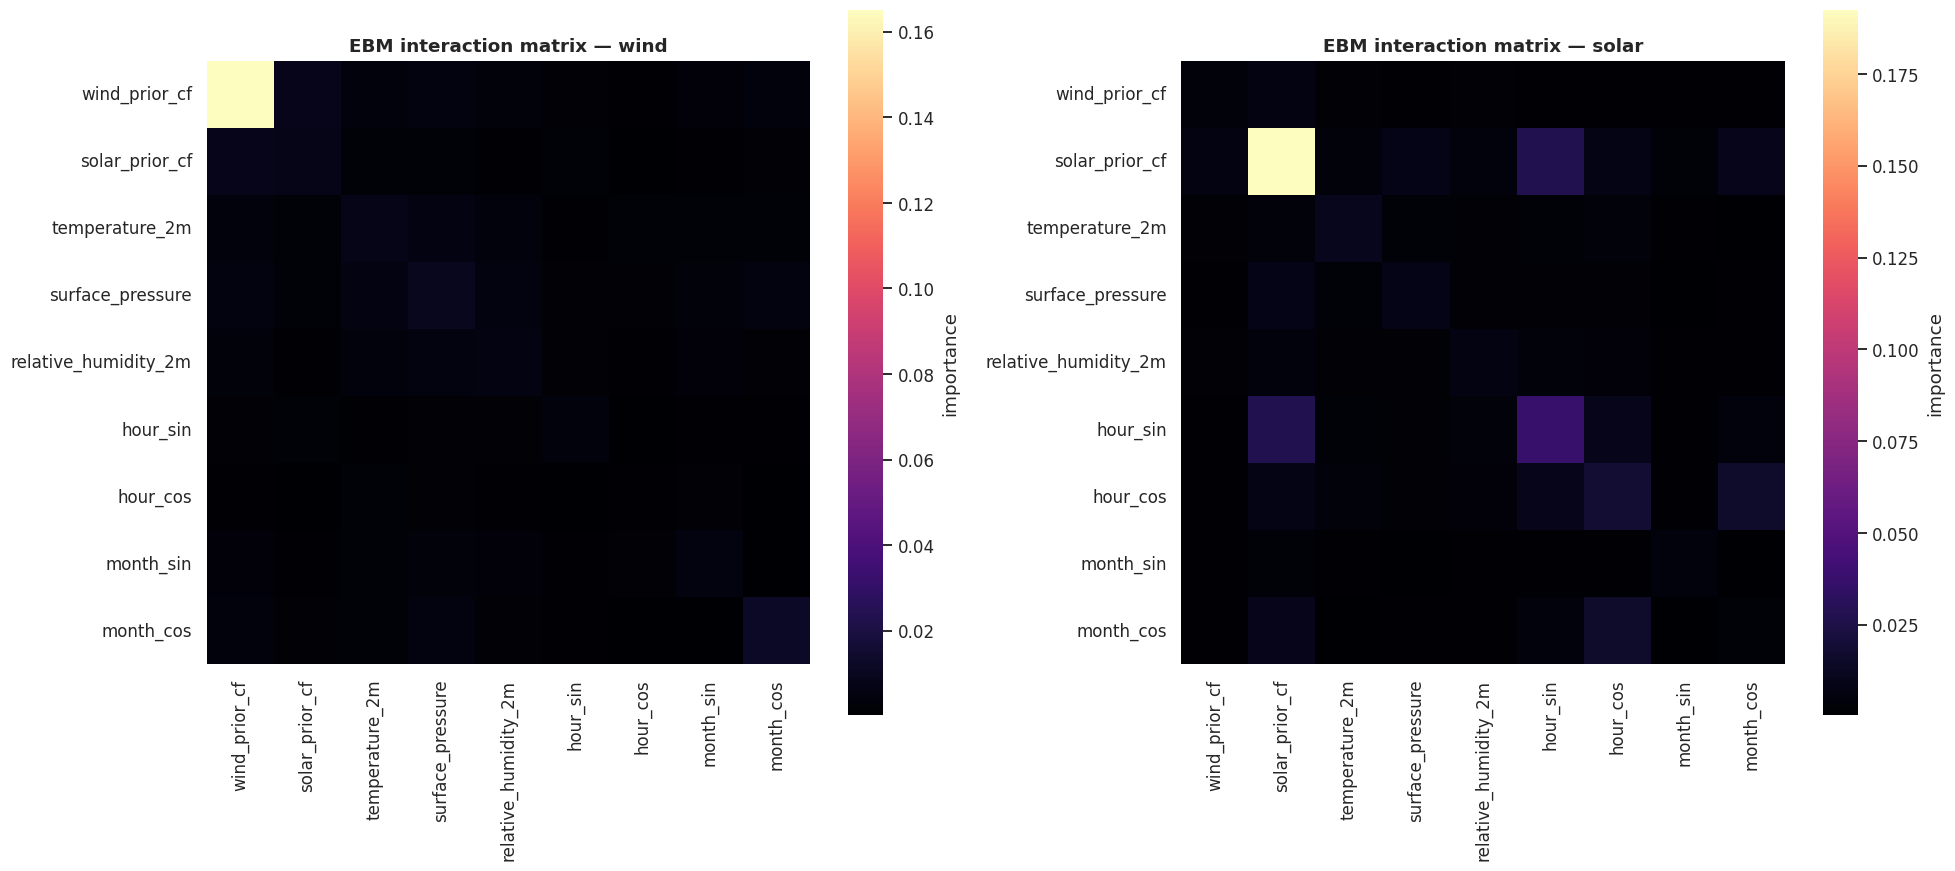

In [4]:
from src.features.schema import FEATURE_COLS
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, tech in zip(axes, ["wind","solar"]):
    imp = pd.read_csv(f"results/ebm_{tech}_importance.csv")
    M = pd.DataFrame(0.0, index=FEATURE_COLS, columns=FEATURE_COLS)
    for _, row in imp.iterrows():
        feat, score = row["Feature"], row["ImportanceScore"]
        if " & " in feat:
            a, b = feat.split(" & ")
            if a in M.index and b in M.columns:
                M.loc[a, b] = score; M.loc[b, a] = score
        elif feat in M.index:
            M.loc[feat, feat] = score
    sns.heatmap(M, ax=ax, cmap="magma", square=True, cbar_kws={"label":"importance"})
    ax.set_title(f"EBM interaction matrix — {tech}")
fig.tight_layout(); save(fig, "s3_ebm_interaction_heatmap.png"); plt.show()

## 3c — Top pairwise interactions (ranked)

saved -> results/figures/s3_ebm_top_interactions.png


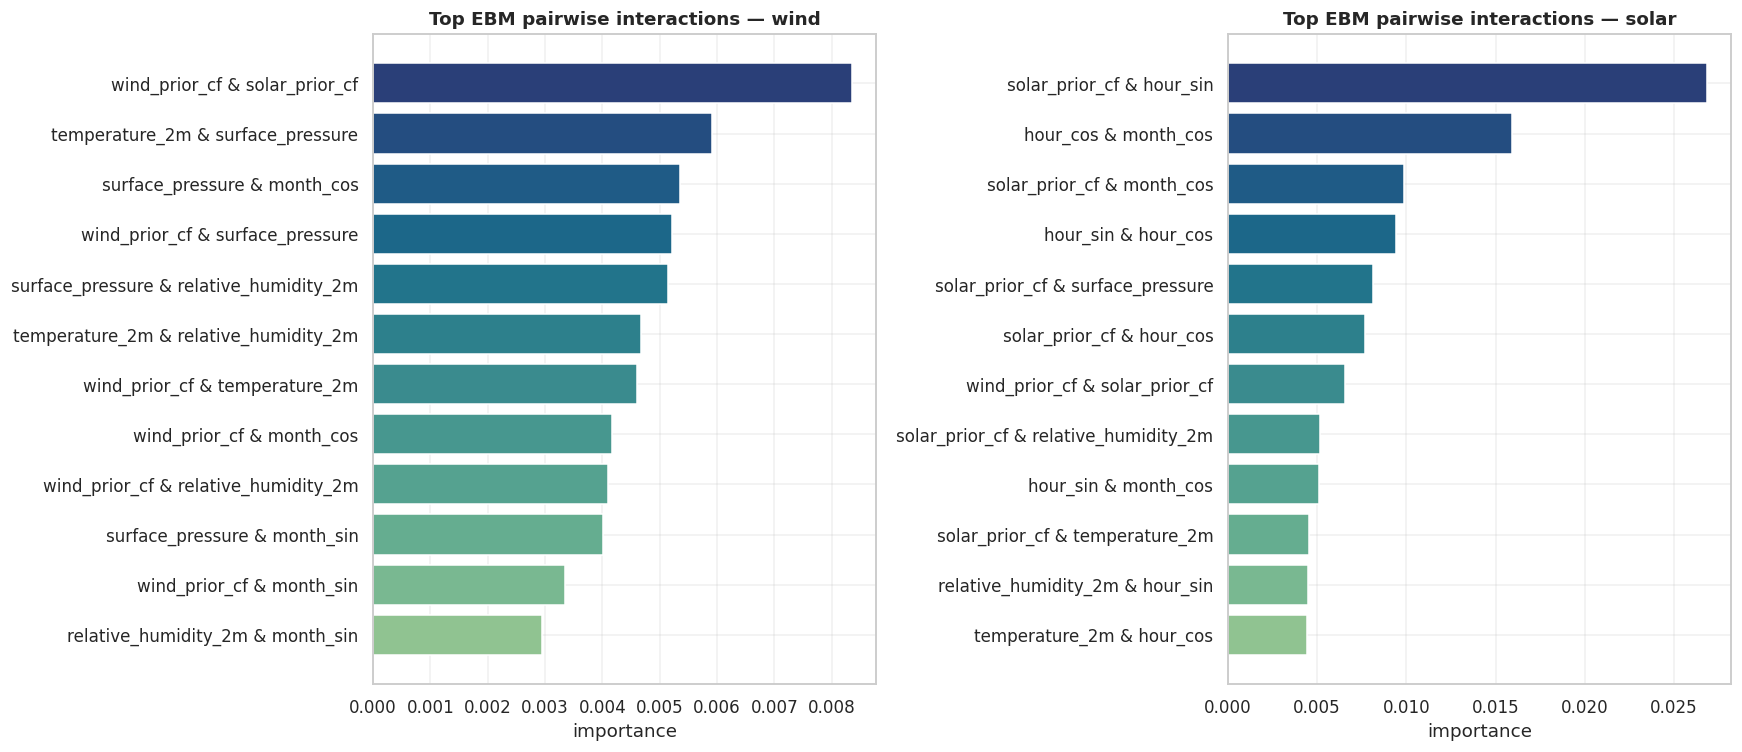

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, tech in zip(axes, ["wind","solar"]):
    imp = pd.read_csv(f"results/ebm_{tech}_importance.csv")
    pair = imp[imp["Feature"].str.contains(" & ")].head(12).iloc[::-1]
    ax.barh(pair["Feature"], pair["ImportanceScore"], color=sns.color_palette("crest", len(pair)))
    ax.set_title(f"Top EBM pairwise interactions — {tech}"); ax.set_xlabel("importance")
fig.tight_layout(); save(fig, "s3_ebm_top_interactions.png"); plt.show()

## 3d — TFT attention over time (from explain_tft.py artefacts)

Re-verify the solar 72-hour attention spike and wind autoregressive attention. These are embedded from the trained-checkpoint explanation run.

saved -> results/figures/s3_tft_attention.png


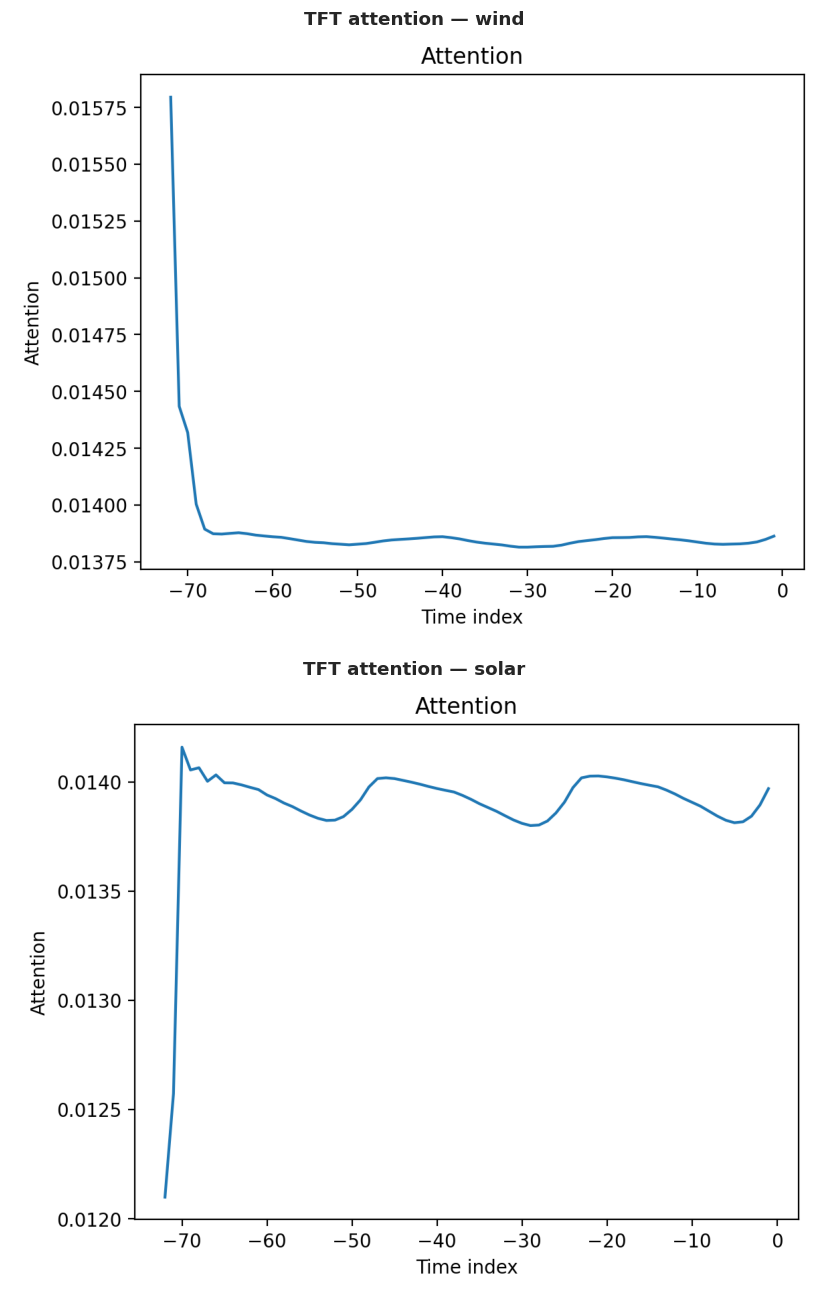

In [6]:
import matplotlib.image as mpimg, shutil
srcs = {"wind": "results/tft_wind_attention.png", "solar": "results/tft_solar_attention.png"}
fig, axes = plt.subplots(2, 1, figsize=(13, 12))
for ax, (tech, src) in zip(axes, srcs.items()):
    if os.path.exists(src):
        ax.imshow(mpimg.imread(src)); ax.set_title(f"TFT attention — {tech}")
        shutil.copy(src, os.path.join(FIG, f"s3_tft_{tech}_attention.png"))
    else:
        ax.text(0.5, 0.5, f"missing {src}\nrun: uv run -m src.models.explain_tft",
                ha="center", va="center")
    ax.axis("off")
fig.tight_layout(); save(fig, "s3_tft_attention.png"); plt.show()